## Risk-Taking vs Avoidance
This chart shows how many bats took risks (1) or avoided them (0) during their landings.  
It helps us understand whether bats generally behave boldly or cautiously when rats are present.

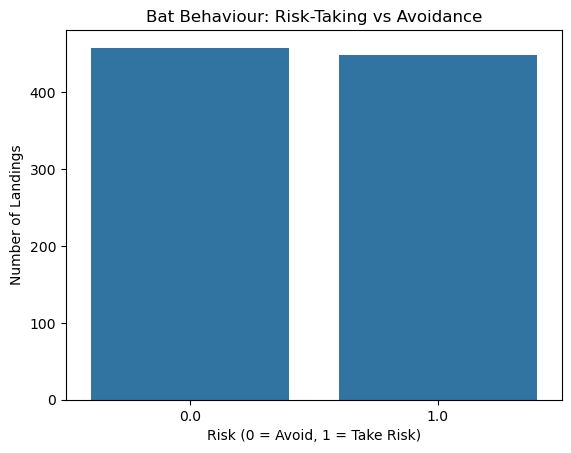

In [10]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv("dataset1_clean.csv")
df2 = pd.read_csv("dataset2_clean.csv")

sns.countplot(data=df1, x='risk')
plt.title("Bat Behaviour: Risk-Taking vs Avoidance")
plt.xlabel("Risk (0 = Avoid, 1 = Take Risk)")
plt.ylabel("Number of Landings")
plt.show()

## Do Risk-Taking Bats Get Rewarded?  
This chart compares how often bats were rewarded with food based on whether they took risks or not.  
It helps us see if risk-taking actually increases the chance of getting food.

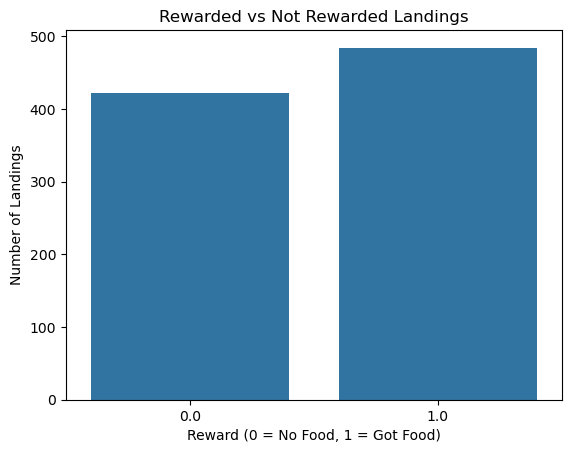

In [11]:
sns.countplot(data=df1, x='reward')
plt.title("Rewarded vs Not Rewarded Landings")
plt.xlabel("Reward (0 = No Food, 1 = Got Food)")
plt.ylabel("Number of Landings")
plt.show()

## Boxplot: Seconds after rat arrival by risk level
This boxplot shows how long bats waited after rats arrived before landing, split by risk behaviour.  
If risk-takers land sooner, it suggests bolder behaviour around rats.

In [3]:
if "sec_since_rat_arrival" in df1.columns:
    sns.boxplot(data=df1, x="risk", y="sec_since_rat_arrival")
    plt.title("Do Risk-Takers Land Sooner After Rat Arrival?")
    plt.xlabel("Risk Behaviour")
    plt.ylabel("Seconds Since Rat Arrival")
    plt.show()

## Risk Behaviour in Different Seasons
This chart shows how bat risk behaviour changes across seasons.  
It helps us check if bats behave differently in spring, summer, winter, or autumn.

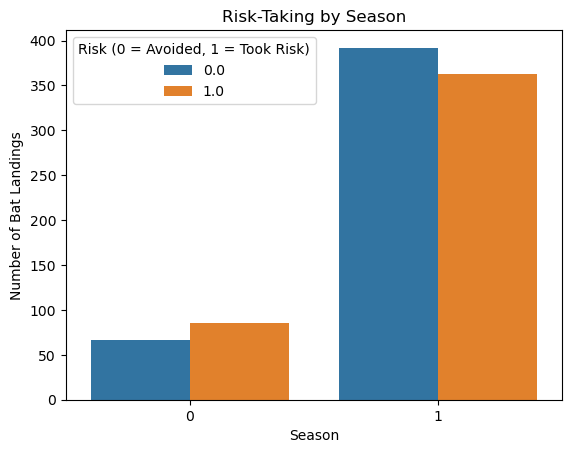

In [4]:
# Risk-Taking by Season

sns.countplot(data=df1, x='season', hue='risk')
plt.title("Risk-Taking by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bat Landings")
plt.legend(title="Risk (0 = Avoided, 1 = Took Risk)")
plt.show()

This boxplot shows how long bats waited after rats arrived before landing, split by risk behaviour.  
If risk-takers land sooner, it suggests bolder behaviour around rats.

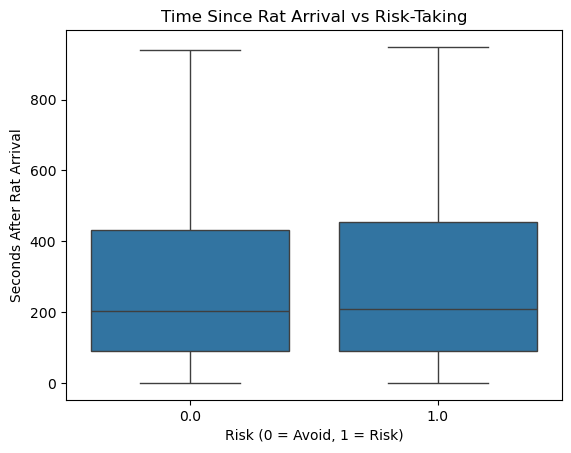

In [5]:
# Time After Rat Arrival vs Risk (Boxplot)

sns.boxplot(data=df1, x='risk', y='seconds_after_rat_arrival')
plt.title("Time Since Rat Arrival vs Risk-Taking")
plt.xlabel("Risk (0 = Avoid, 1 = Risk)")
plt.ylabel("Seconds After Rat Arrival")
plt.show()

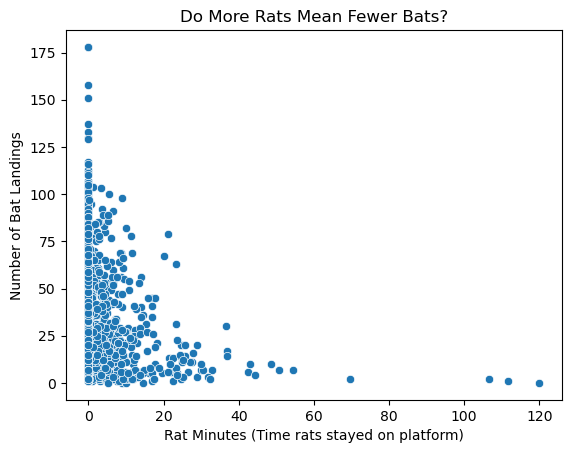

In [6]:
# Rat Presence vs Bat Landings (Scatterplot from dataset2)

sns.scatterplot(data=df2, x='rat_minutes', y='bat_landing_number')
plt.title("Do More Rats Mean Fewer Bats?")
plt.xlabel("Rat Minutes (Time rats stayed on platform)")
plt.ylabel("Number of Bat Landings")
plt.show()

## Are Risk-Takers More Rewarded in Some Seasons?  
This chart shows how often bats were rewarded in each season, separated by their risk behaviour.  
It helps us see if risk is more successful in some seasons than others.

Text(0.5, 0.98, 'How Risk and Season Affect Rewards')

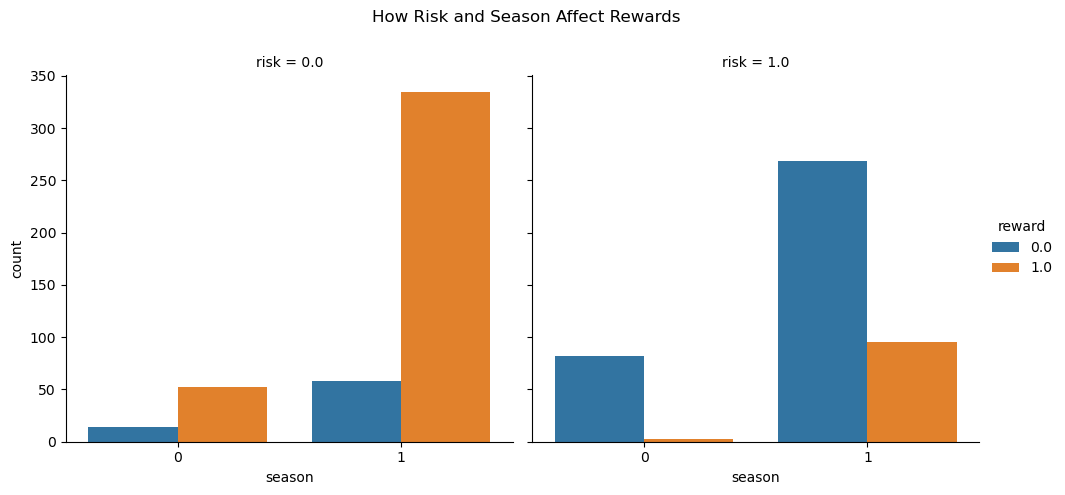

In [12]:
sns.catplot(data=df1, x="season", hue="reward", col="risk", kind="count")
plt.subplots_adjust(top=0.85)
plt.suptitle("How Risk and Season Affect Rewards")

## Which Numeric Features Are Related?  
This heatmap shows how different numeric columns are related to each other.  
It helps us find patterns or connections between timing, risk, reward, and other features.

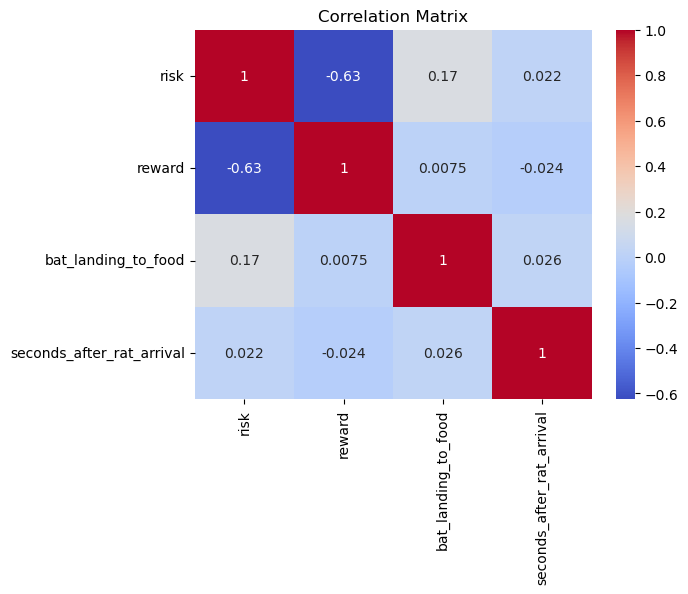

In [8]:
# Correlation Heatmap
sns.heatmap(df1[['risk', 'reward', 'bat_landing_to_food', 'seconds_after_rat_arrival']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Descriptive Analytics
This section summarises the central tendency, spread, distribution shape, and basic relationships in the cleaned datasets.


In [2]:
import pandas as pd
import numpy as np

# Load your cleaned datasets first
df1 = pd.read_csv("dataset1_clean.csv")
df2 = pd.read_csv("dataset2_clean.csv")

# Quick check
display(df1.head())
display(df2.head())


,start_time,bat_landing_to_food,habit,rat_period_start,rat_period_end,seconds_after_rat_arrival,risk,reward,month,sunset_time,hours_after_sunset,season
0,2017-12-30 18:37:00,16.000000,rat,2017-12-30 18:35:00,2017-12-30 18:38:00,108.0,1.0,0.0,0,2017-12-30 16:45:00,1.870833,0
1,2017-12-30 19:51:00,0.074016,fast,2017-12-30 19:50:00,2017-12-30 19:55:00,17.0,0.0,1.0,0,2017-12-30 16:45:00,3.100833,0
2,2017-12-30 19:51:00,4.000000,fast,2017-12-30 19:50:00,2017-12-30 19:55:00,41.0,0.0,1.0,0,2017-12-30 16:45:00,3.107500,0
3,2017-12-30 19:52:00,10.000000,rat,2017-12-30 19:50:00,2017-12-30 19:55:00,111.0,1.0,0.0,0,2017-12-30 16:45:00,3.126944,0
4,2017-12-30 19:54:00,15.000000,rat,2017-12-30 19:50:00,2017-12-30 19:55:00,194.0,1.0,0.0,0,2017-12-30 16:45:00,3.150000,0


,time,month,hours_after_sunset,bat_landing_number,food_availability,rat_minutes,rat_arrival_number
0,2017-12-26 16:13:00,0,NaN,20,4.000000,0.0,0
1,2017-12-26 16:43:00,0,0.0,28,4.000000,0.0,0
2,2017-12-26 17:13:00,0,0.5,25,4.000000,0.0,0
3,2017-12-26 17:43:00,0,1.0,71,4.000000,0.0,0
4,2017-12-26 18:13:00,0,1.5,44,3.753857,0.0,0


In [3]:
# Assumes df1 and df2 already loaded:
# df1 = pd.read_csv("dataset1_clean.csv")
# df2 = pd.read_csv("dataset2_clean.csv")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- helpers ----
def numeric_cols(df):
    return df.select_dtypes(include=np.number).columns.tolist()

def categorical_cols(df):
    return df.select_dtypes(exclude=np.number).columns.tolist()

def show_table(name, tbl):
    print(name)
    display(tbl)

# 1) FULL describe (incl. categorical)
show_table("=== Dataset 1: describe(all) ===", df1.describe(include="all").T)
show_table("=== Dataset 2: describe(all) ===", df2.describe(include="all").T)

# 2) Central tendency & dispersion (numeric only)
num1, num2 = numeric_cols(df1), numeric_cols(df2)

desc1 = pd.DataFrame({
    "Mean": df1[num1].mean(),
    "Median": df1[num1].median(),
    "Std Dev": df1[num1].std(),
    "Min": df1[num1].min(),
    "Max": df1[num1].max(),
    "IQR": df1[num1].quantile(0.75) - df1[num1].quantile(0.25)
}).round(3)

desc2 = pd.DataFrame({
    "Mean": df2[num2].mean(),
    "Median": df2[num2].median(),
    "Std Dev": df2[num2].std(),
    "Min": df2[num2].min(),
    "Max": df2[num2].max(),
    "IQR": df2[num2].quantile(0.75) - df2[num2].quantile(0.25)
}).round(3)

show_table("=== Dataset 1: central tendency & dispersion ===", desc1)
show_table("=== Dataset 2: central tendency & dispersion ===", desc2)

# 3) Distribution shape (skewness & kurtosis)
shape1 = pd.DataFrame({
    "Skewness": df1[num1].skew(),
    "Kurtosis": df1[num1].kurt()
}).round(3)

shape2 = pd.DataFrame({
    "Skewness": df2[num2].skew(),
    "Kurtosis": df2[num2].kurt()
}).round(3)

show_table("=== Dataset 1: distribution shape ===", shape1)
show_table("=== Dataset 2: distribution shape ===", shape2)

# 4) Categorical frequency / proportions (top 10)
for col in categorical_cols(df1):
    freq = (df1[col].value_counts(dropna=False, normalize=True) * 100).round(2).head(10)
    show_table(f"Dataset 1 — Frequency (%) for {col}", freq.to_frame("Proportion %"))

for col in categorical_cols(df2):
    freq = (df2[col].value_counts(dropna=False, normalize=True) * 100).round(2).head(10)
    show_table(f"Dataset 2 — Frequency (%) for {col}", freq.to_frame("Proportion %"))


=== Dataset 1: describe(all) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
start_time,906,628,2018-04-21 02:17:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bat_landing_to_food,906.0,NaN,NaN,NaN,11.720544,27.658777,0.010238,1.0,4.0,11.75,443.0
habit,865,81,fast,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rat_period_start,906,268,2018-04-26 22:25:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rat_period_end,906,268,2018-04-26 22:36:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seconds_after_rat_arrival,906.0,NaN,NaN,NaN,282.786976,241.092545,0.0,89.25,206.0,447.25,949.0
risk,906.0,NaN,NaN,NaN,0.494481,0.500246,0.0,0.0,0.0,1.0,1.0
reward,906.0,NaN,NaN,NaN,0.534216,0.499103,0.0,0.0,1.0,1.0,1.0
month,906.0,NaN,NaN,NaN,3.800221,1.199834,0.0,4.0,4.0,5.0,5.0
sunset_time,906,65,2018-04-26 19:17:00,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== Dataset 2: describe(all) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
time,2123,2123,2017-12-26 16:13:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,2123.0,NaN,NaN,NaN,3.083844,1.642261,0.0,2.0,4.0,4.0,6.0
hours_after_sunset,1911.0,NaN,NaN,NaN,5.973574,3.660845,0.0,3.0,6.0,9.0,13.5
bat_landing_number,2123.0,NaN,NaN,NaN,32.083373,25.614431,0.0,11.0,27.0,48.0,178.0
food_availability,2123.0,NaN,NaN,NaN,2.445874,1.218353,0.0,1.962206,2.951877,3.105873,4.0
rat_minutes,2123.0,NaN,NaN,NaN,1.994442,6.793397,0.0,0.0,0.0,0.158333,120.0
rat_arrival_number,2123.0,NaN,NaN,NaN,0.444654,1.019195,0.0,0.0,0.0,1.0,17.0


=== Dataset 1: central tendency & dispersion ===


...

,Proportion %
2018-04-26 22:36:00,3.20
2018-05-01 00:44:00,2.21
2018-04-03 01:21:00,1.99
2018-04-20 00:18:00,1.77
2018-01-28 20:10:00,1.66
2018-04-30 01:44:00,1.55
2018-04-04 00:58:00,1.43
2018-04-29 03:06:00,1.43
2018-04-21 02:18:00,1.43
2018-04-28 00:14:00,1.43


Dataset 1 — Frequency (%) for sunset_time


,Proportion %
2018-04-26 19:17:00,11.15
2018-04-28 19:19:00,7.84
2018-04-19 19:12:00,5.85
2018-04-27 19:18:00,5.52
2018-04-30 19:20:00,5.30
2018-04-29 19:19:00,4.53
2018-04-02 19:01:00,4.42
2018-05-03 19:22:00,3.86
2018-04-21 19:14:00,3.75
2018-04-20 19:13:00,3.53


Dataset 2 — Frequency (%) for time


,Proportion %
2017-12-26 16:13:00,0.05
2018-04-24 01:45:00,0.05
2018-04-24 18:16:00,0.05
2018-04-24 17:46:00,0.05
2018-04-24 17:16:00,0.05
2018-04-24 08:15:00,0.05
2018-04-24 06:45:00,0.05
2018-04-24 06:15:00,0.05
2018-04-24 05:45:00,0.05
2018-04-24 05:15:00,0.05


### Visualisations
- Histograms for key numeric columns  
- Boxplots to compare distributions across groups (if `risk` / `reward` exist)  
- Correlation heatmap (numeric variables only)


<Figure size 432x288 with 0 Axes>

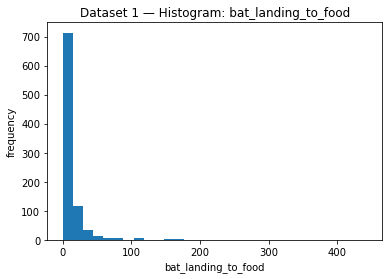

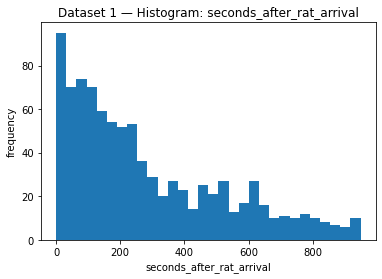

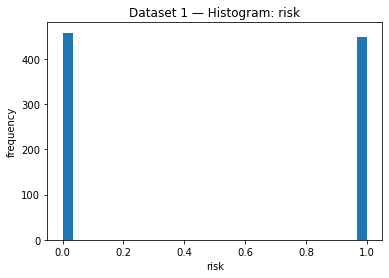

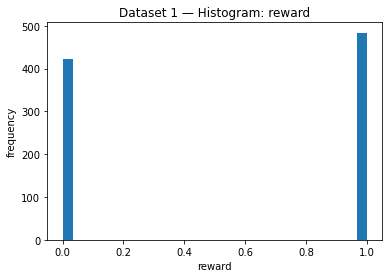

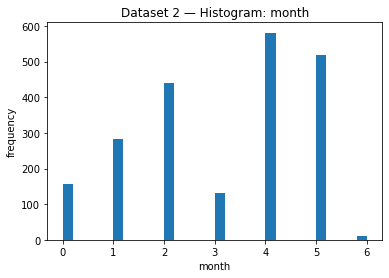

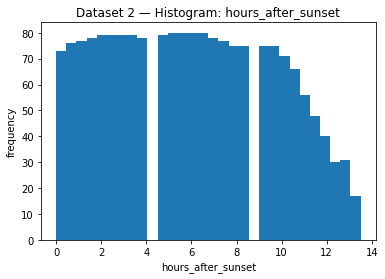

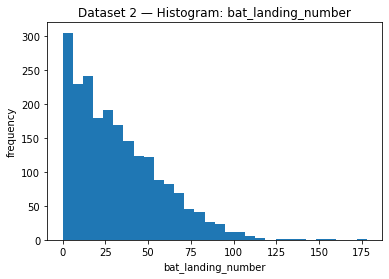

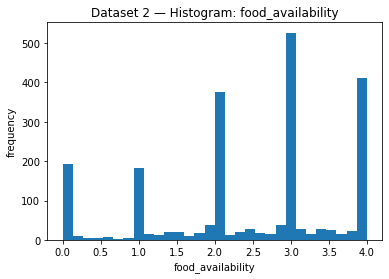

In [4]:
# ---------- HISTOGRAMS ----------
# pick up to 4 numeric columns from each dataset for quick inspection
def first_n(seq, n=4): return seq[:min(n, len(seq))]

plt.figure()
for col in first_n(numeric_cols(df1), 4):
    plt.figure()
    plt.hist(df1[col].dropna(), bins=30)
    plt.title(f"Dataset 1 — Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

for col in first_n(numeric_cols(df2), 4):
    plt.figure()
    plt.hist(df2[col].dropna(), bins=30)
    plt.title(f"Dataset 2 — Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()


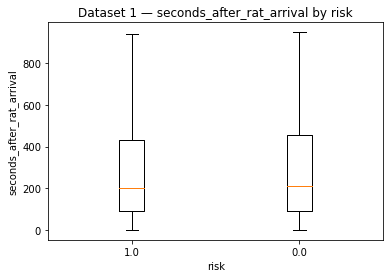

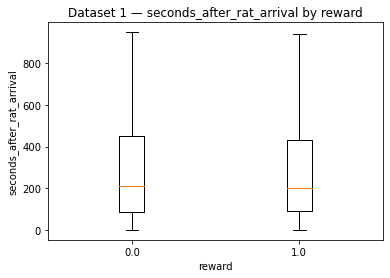

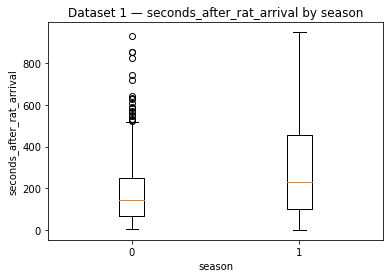

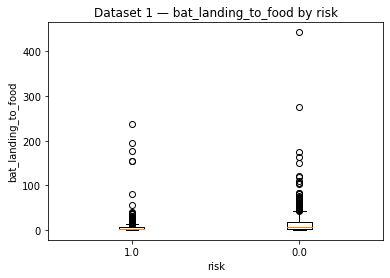

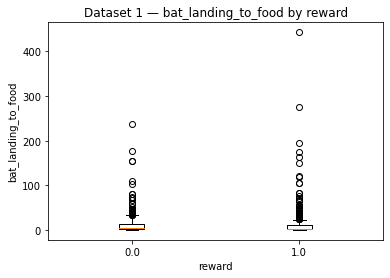

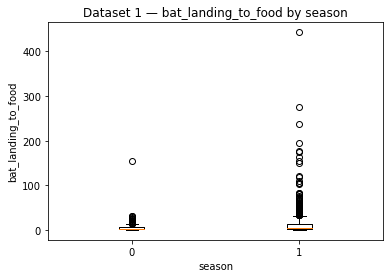

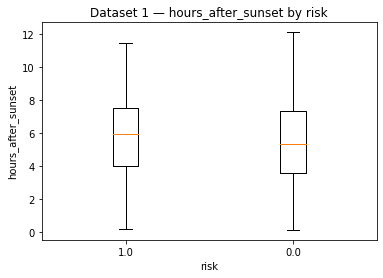

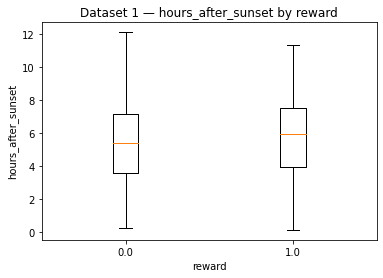

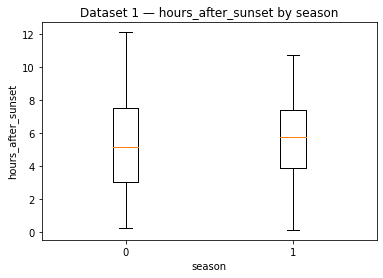

In [5]:
# ---------- BOXPLOTS BY GROUP ----------
# If these columns exist, show distributions across levels
def boxplot_by_category(df, num_col, cat_col, dsname="Dataset"):
    if num_col in df.columns and cat_col in df.columns:
        groups = [g.dropna() for _, g in df.groupby(cat_col)[num_col]]
        labels = [str(k) for k in df[cat_col].dropna().unique().tolist()]
        if len(groups) > 0:
            plt.figure()
            plt.boxplot(groups, labels=labels)
            plt.title(f"{dsname} — {num_col} by {cat_col}")
            plt.xlabel(cat_col)
            plt.ylabel(num_col)
            plt.show()

# Common combos used in your analysis; change if your column names differ
candidates_num = ["seconds_after_rat_arrival","bat_landing_to_food","hours_after_sunset",
                  "rat_minutes","bat_landing_number"]
cats = ["risk","reward","season"]

for num_col in candidates_num:
    for cat_col in cats:
        boxplot_by_category(df1, num_col, cat_col, dsname="Dataset 1")
        boxplot_by_category(df2, num_col, cat_col, dsname="Dataset 2")


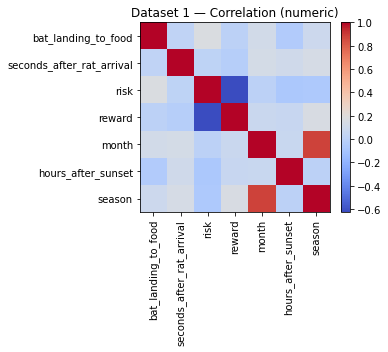

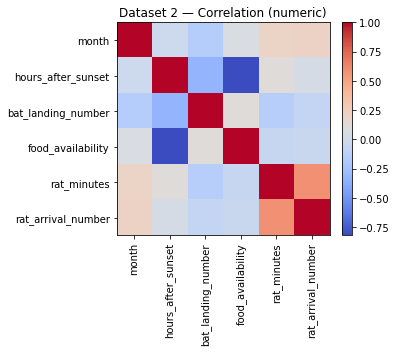

In [7]:
# ---------- CORRELATION HEATMAP (fixed for all pandas versions) ----------
import matplotlib.pyplot as plt

def corr_heatmap(df, title="Correlation (numeric)"):
    # Select only numeric columns manually
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print("No numeric columns for correlation.")
        return
    corr = num.corr()  # removed numeric_only argument
    plt.figure(figsize=(6,5))
    im = plt.imshow(corr, interpolation="nearest", cmap='coolwarm')
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = range(len(corr.columns))
    plt.xticks(ticks, corr.columns, rotation=90)
    plt.yticks(ticks, corr.columns)
    plt.tight_layout()
    plt.show()

corr_heatmap(df1, "Dataset 1 — Correlation (numeric)")
corr_heatmap(df2, "Dataset 2 — Correlation (numeric)")


### Interpretation Notes (edit to match your variables)
- **Central tendency**: mean vs median alignment suggests symmetry; bigger gaps imply skew.  
- **Spread**: higher standard deviation/IQR → more variability in behaviour.  
- **Skewness/Kurtosis**: positive skew = right tail; kurtosis > 3 suggests heavier tails/outliers.  
- **Histograms**: check for multi-modality (multiple peaks) hinting at subgroups.  
- **Boxplots by risk/reward/season**: median shifts or IQR changes indicate group differences.  
- **Correlation heatmap**: strong |r| close to 1 suggests linear relationships worth probing further.
